### Binary and Ternary Classes in This Study Based on Mohs Hardness Values
Binary
0: (0.991, 5.5]
1: (5.5, 10.0]

Ternary
0: (0.991, 4.0]
1: (4.0, 7.0]
2: (7.0, 10.0]

### List of all Primary Features
- `allelectrons_Total`
- `density_Total`
- `allelectrons_Average`
- `val_e_Average`
- `atomicweight_Average`
- `ionenergy_Average`
- `el_neg_chi_Average`
- `R_vdw_element_Average`
- `R_cov_element_Average`
- `zaratio_Average`
- `density_Average`

### Train and Test Datasets
Train: Artificial_Crystals_Dataset.csv
Test: Mineral_Dataset_Supplementary_Info.csv

### ML Models Used
1. Binary RBF SVC
2. Ternary RBF SVC - OVO
3. Binary RF
4. Ternary RF - multiclass
5. Ternary RF - OVR: 0 versus 1, 2
6. Ternary RF - OVR: 1 versus 0, 2
7. Ternary RF - OVR: 2 versus 0, 1
8. Binary Matern SVC
9. Ternary Matern SVC - OVO

In [29]:
from pathlib import Path
import csv
from typing import Callable, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.gaussian_process.kernels import Matern
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [30]:
FEATURES = [
    "allelectrons_Total",
    "density_Total",
    "allelectrons_Average",
    "val_e_Average",
    "atomicweight_Average",
    "ionenergy_Average",
    "el_neg_chi_Average",
    "R_vdw_element_Average",
    "R_cov_element_Average",
    "zaratio_Average",
    "density_Average",
]

In [31]:
def binary_label_from_value(hardness: float) -> Optional[int]:
    if 0.991 < hardness <= 5.5:
        return 0
    if 5.5 < hardness <= 10.0:
        return 1
    return None


def ternary_label_from_value(hardness: float) -> Optional[int]:
    if 0.991 < hardness <= 4.0:
        return 0
    if 4.0 < hardness <= 7.0:
        return 1
    if 7.0 < hardness <= 10.0:
        return 2
    return None


def load_xy(csv_path: Path, hardness_column: str, label_fn=binary_label_from_value) -> Tuple[np.ndarray, np.ndarray]:
    x_rows = []
    y_rows = []
    with csv_path.open(newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                hardness = float(row[hardness_column])
                label_value = label_fn(hardness)
                if label_value is None:
                    continue
                feature_vector = [float(row[feature]) for feature in FEATURES]
            except (TypeError, ValueError, KeyError):
                continue
            x_rows.append(feature_vector)
            y_rows.append(label_value)
    return np.array(x_rows, dtype=float), np.array(y_rows, dtype=int)


def calculate_specificity(y_true: np.ndarray, y_pred: np.ndarray, labels: list[int]) -> float:
    if len(labels) == 2:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=labels).ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else 0.0

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    per_class_specificity = []
    for class_idx in range(cm.shape[0]):
        tp = cm[class_idx, class_idx]
        fp = cm[:, class_idx].sum() - tp
        fn = cm[class_idx, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        class_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        per_class_specificity.append(class_specificity)
    return float(np.mean(per_class_specificity))


def evaluate_fold(y_true: np.ndarray, y_pred: np.ndarray, labels: list[int]) -> dict[str, float]:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    accuracy = accuracy_score(y_true, y_pred)
    specificity = calculate_specificity(y_true, y_pred, labels=labels)
    return {
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy,
        "f1": f1,
        "specificity": specificity,
    }


def summarize_metric_series(metric_series: dict[str, list[float]]) -> dict[str, dict[str, float]]:
    return {
        metric_name: {
            "mean": float(np.array(values).mean()),
            "std": float(np.array(values).std(ddof=1)),
        }
        for metric_name, values in metric_series.items()
    }


def evaluate_with_splitter(
    X_data: np.ndarray,
    y_data: np.ndarray,
    labels: list[int],
    predictor: Callable[[np.ndarray, np.ndarray, np.ndarray], np.ndarray],
    n_splits: int = 500,
) -> dict[str, dict[str, float]]:
    splitter = StratifiedShuffleSplit(n_splits=n_splits, train_size=2 / 3, test_size=1 / 3, random_state=42)
    metric_series = {
        "precision": [],
        "recall": [],
        "accuracy": [],
        "f1": [],
        "specificity": [],
    }

    for train_index, test_index in splitter.split(X_data, y_data):
        X_train, X_test = X_data[train_index], X_data[test_index]
        y_train, y_test = y_data[train_index], y_data[test_index]

        y_pred = predictor(X_train, y_train, X_test)
        fold_metrics = evaluate_fold(y_test, y_pred, labels=labels)

        for metric_name, value in fold_metrics.items():
            metric_series[metric_name].append(value)

    return summarize_metric_series(metric_series)


def make_standard_predictor(model) -> Callable[[np.ndarray, np.ndarray, np.ndarray], np.ndarray]:
    def predictor(X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray) -> np.ndarray:
        model.fit(X_train, y_train)
        return model.predict(X_test)

    return predictor


def make_matern_predictor(model, kernel: Matern) -> Callable[[np.ndarray, np.ndarray, np.ndarray], np.ndarray]:
    def predictor(X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray) -> np.ndarray:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        K_train = kernel(X_train_scaled, X_train_scaled)
        K_test = kernel(X_test_scaled, X_train_scaled)

        model.fit(K_train, y_train)
        return model.predict(K_test)

    return predictor


def add_model_results(model_performance: dict[str, dict[str, dict[str, float]]], model_name: str, metric_stats: dict[str, dict[str, float]]) -> None:
    model_performance[model_name] = metric_stats
    for metric_name in ["precision", "recall", "accuracy", "f1", "specificity"]:
        stats = metric_stats[metric_name]
        print(f"{metric_name.capitalize()}: {stats['mean']:.4f} ± {stats['std']:.4f}")

In [32]:
# Get path and load data
base_dir = Path("/Users/owensizemore/code/duke/aimaterials/m5")
if not base_dir.exists():
    base_dir = Path("m5")

X, y = load_xy(base_dir / "Mineral_Dataset_Supplementary_Info.csv", "Hardness")

### 1: Binary RBF SVC

In [33]:
model_performance = {}
rbf_svc_binary = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale", random_state=42)),
    ]
)
metric_stats = evaluate_with_splitter(
    X_data=X,
    y_data=y,
    labels=[0, 1],
    predictor=make_standard_predictor(rbf_svc_binary),
)
add_model_results(model_performance, "rbf_svc_binary", metric_stats)


Precision: 0.8369 ± 0.0236
Recall: 0.8360 ± 0.0239
Accuracy: 0.8360 ± 0.0239
F1: 0.8357 ± 0.0238
Specificity: 0.8798 ± 0.0298


### 2. Ternary RBF SVC - OVO

In [34]:
X_ternary, y_ternary = load_xy(
    base_dir / "Mineral_Dataset_Supplementary_Info.csv",
    "Hardness",
    label_fn=ternary_label_from_value,
)
rbf_svc_ternary = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale", decision_function_shape="ovo", random_state=42)),
    ]
)
metric_stats = evaluate_with_splitter(
    X_data=X_ternary,
    y_data=y_ternary,
    labels=[0, 1, 2],
    predictor=make_standard_predictor(rbf_svc_ternary),
)
add_model_results(model_performance, "rbf_svc_ternary_ovo", metric_stats)

Precision: 0.7942 ± 0.0304
Recall: 0.8053 ± 0.0228
Accuracy: 0.8053 ± 0.0228
F1: 0.7908 ± 0.0236
Specificity: 0.8638 ± 0.0156


### 3. Binary RF

In [35]:
rf_binary = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
metric_stats = evaluate_with_splitter(
    X_data=X,
    y_data=y,
    labels=[0, 1],
    predictor=make_standard_predictor(rf_binary),
)
add_model_results(model_performance, "rf_binary", metric_stats)

Precision: 0.8624 ± 0.0212
Recall: 0.8631 ± 0.0205
Accuracy: 0.8631 ± 0.0205
F1: 0.8607 ± 0.0210
Specificity: 0.9250 ± 0.0248


### 4. Ternary RF - multiclass

In [36]:
rf_ternary_multiclass = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
metric_stats = evaluate_with_splitter(
    X_data=X_ternary,
    y_data=y_ternary,
    labels=[0, 1, 2],
    predictor=make_standard_predictor(rf_ternary_multiclass),
)
add_model_results(model_performance, "rf_ternary_multiclass", metric_stats)

Precision: 0.8430 ± 0.0251
Recall: 0.8487 ± 0.0209
Accuracy: 0.8487 ± 0.0209
F1: 0.8399 ± 0.0214
Specificity: 0.8994 ± 0.0139


### 5. Ternary RF - OVR: 0 versus 1, 2

In [37]:
y_ternary_ovr_0 = np.where(y_ternary == 0, 0, 1)
rf_ternary_ovr_0 = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
metric_stats = evaluate_with_splitter(
    X_data=X_ternary,
    y_data=y_ternary_ovr_0,
    labels=[0, 1],
    predictor=make_standard_predictor(rf_ternary_ovr_0),
)
add_model_results(model_performance, "rf_ternary_ovr_0_vs_12", metric_stats)

Precision: 0.8864 ± 0.0207
Recall: 0.8855 ± 0.0208
Accuracy: 0.8855 ± 0.0208
F1: 0.8854 ± 0.0208
Specificity: 0.8530 ± 0.0408


### 6. Ternary RF - OVR: 1 versus 0, 2

In [38]:
y_ternary_ovr_1 = np.where(y_ternary == 1, 0, 1)
rf_ternary_ovr_1 = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
metric_stats = evaluate_with_splitter(
    X_data=X_ternary,
    y_data=y_ternary_ovr_1,
    labels=[0, 1],
    predictor=make_standard_predictor(rf_ternary_ovr_1),
)
add_model_results(model_performance, "rf_ternary_ovr_1_vs_02", metric_stats)

Precision: 0.8520 ± 0.0222
Recall: 0.8510 ± 0.0221
Accuracy: 0.8510 ± 0.0221
F1: 0.8508 ± 0.0222
Specificity: 0.8719 ± 0.0321


### 7. Ternary RF - OVR: 2 versus 0, 1

In [39]:
y_ternary_ovr_2 = np.where(y_ternary == 2, 0, 1)
rf_ternary_ovr_2 = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
metric_stats = evaluate_with_splitter(
    X_data=X_ternary,
    y_data=y_ternary_ovr_2,
    labels=[0, 1],
    predictor=make_standard_predictor(rf_ternary_ovr_2),
)
add_model_results(model_performance, "rf_ternary_ovr_2_vs_01", metric_stats)

Precision: 0.9449 ± 0.0199
Recall: 0.9624 ± 0.0052
Accuracy: 0.9624 ± 0.0052
F1: 0.9486 ± 0.0075
Specificity: 0.0892 ± 0.0923


### 8. Binary Matern SVC

In [40]:
matern_kernel = Matern(length_scale=1.0, nu=1.5)
matern_svc_binary = SVC(kernel="precomputed", C=10, random_state=42)
metric_stats = evaluate_with_splitter(
    X_data=X,
    y_data=y,
    labels=[0, 1],
    predictor=make_matern_predictor(matern_svc_binary, matern_kernel),
)
add_model_results(model_performance, "matern_svc_binary", metric_stats)

Precision: 0.8730 ± 0.0210
Recall: 0.8731 ± 0.0207
Accuracy: 0.8731 ± 0.0207
F1: 0.8720 ± 0.0210
Specificity: 0.9187 ± 0.0243


### 9. Ternary Matern SVC - OVO

In [41]:
matern_kernel = Matern(length_scale=1.0, nu=1.5)
matern_svc_ternary = SVC(kernel="precomputed", C=10, decision_function_shape="ovo", random_state=42)
metric_stats = evaluate_with_splitter(
    X_data=X_ternary,
    y_data=y_ternary,
    labels=[0, 1, 2],
    predictor=make_matern_predictor(matern_svc_ternary, matern_kernel),
)
add_model_results(model_performance, "matern_svc_ternary_ovo", metric_stats)

Precision: 0.8390 ± 0.0226
Recall: 0.8417 ± 0.0211
Accuracy: 0.8417 ± 0.0211
F1: 0.8369 ± 0.0214
Specificity: 0.8951 ± 0.0142


### Visualize Results across All Models

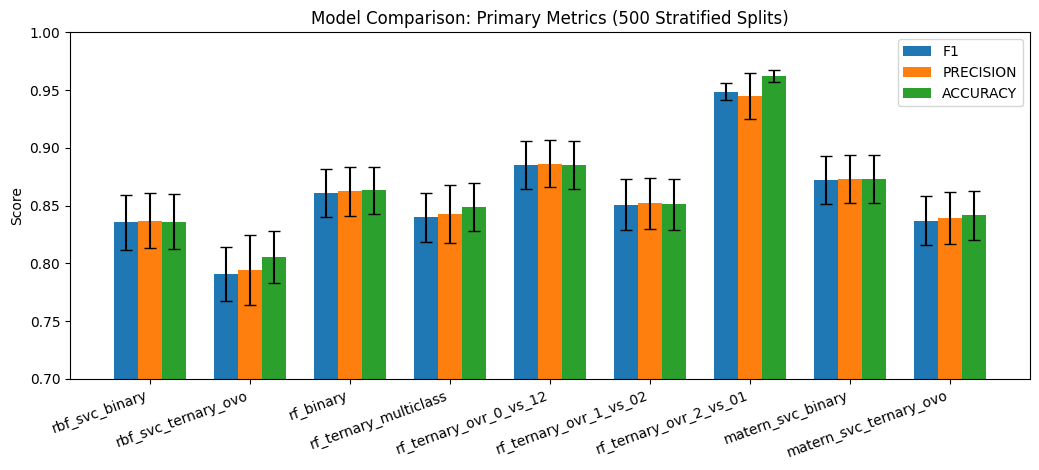

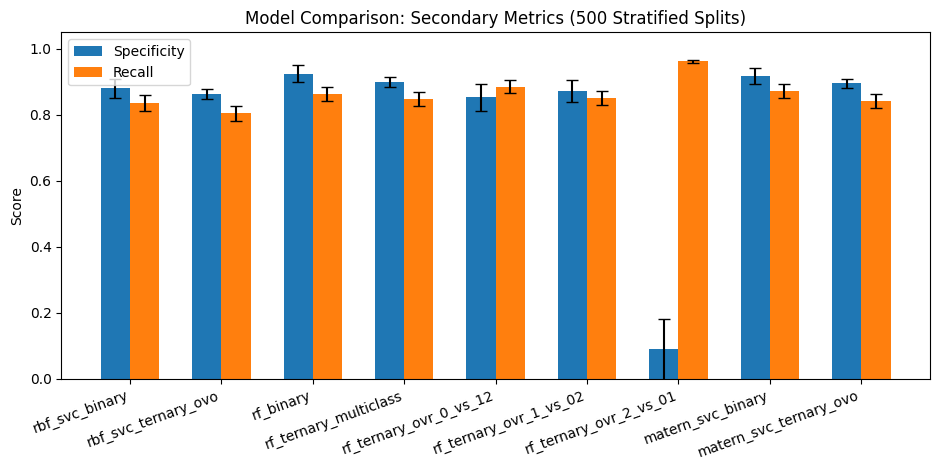

In [42]:
primary_metrics = ["f1", "precision", "accuracy"]
secondary_metrics = ["specificity", "recall"]
model_names = list(model_performance.keys())

fig, ax = plt.subplots(figsize=(10.5, 4.8))
positions = np.arange(len(model_names))
width = 0.24
offsets = np.linspace(-width, width, len(primary_metrics))
for metric_name, offset in zip(primary_metrics, offsets):
    means = [model_performance[model_name][metric_name]["mean"] for model_name in model_names]
    stds = [model_performance[model_name][metric_name]["std"] for model_name in model_names]
    ax.bar(positions + offset, means, width=width, yerr=stds, capsize=4, label=metric_name.upper())
ax.set_xticks(positions)
ax.set_xticklabels(model_names, rotation=20, ha="right")
ax.set_ylim(0.70, 1.00)
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Primary Metrics (500 Stratified Splits)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 4.8))
positions = np.arange(len(model_names))
width = 0.32
offsets = np.linspace(-width / 2, width / 2, len(secondary_metrics))
for metric_name, offset in zip(secondary_metrics, offsets):
    means = [model_performance[model_name][metric_name]["mean"] for model_name in model_names]
    stds = [model_performance[model_name][metric_name]["std"] for model_name in model_names]
    ax.bar(positions + offset, means, width=width, yerr=stds, capsize=4, label=metric_name.capitalize())
ax.set_xticks(positions)
ax.set_xticklabels(model_names, rotation=20, ha="right")
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Secondary Metrics (500 Stratified Splits)")
ax.legend()
plt.tight_layout()
plt.show()